## Introduction

**College Data Mining Project (Clustering & Classification)**

The dataset we're dealing with contains details/features of 150 stores, belonging to Australia's FOODmart and spread across 8 states.

My notebook implements Data Mining techniques that could help us understand the data and extract information from it. We will also attempt a classification technique after extracting labels from the dataset.

Finally, our goal here will be to understand customers' choices and behavior better.

**Content:**

- Preprocessing
- Cleaning
- Outliers
- Normalization/Scaling
- Data Mining Technniques (Clustering)
- K-Means
- Hierarchical
- Unsuccessful Techniques
- KMedoids
- DBSCAN
- HDBSCAN
- Silhouette Score
- Visualization
- Pair Plots
- Scatter Plots
- Pie Charts
- Classification
- Data Splitting
- Random Forest Classifier
- Evaluation Metrics


## Importing & Reading Dataset


In [1]:
#!pip install numpy==1.23.5

In [2]:
#!pip install scikit-learn-extra

In [3]:
# Matrix/DataFrame manipulations
import pandas as pd
import numpy as np

# Preprocessing
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Data Mining Techninques
from sklearn.cluster import KMeans
from sklearn_extra.cluster import KMedoids
from scipy.cluster.hierarchy import dendrogram , fcluster , linkage
from sklearn.cluster import DBSCAN
import hdbscan
from sklearn.neighbors import NearestNeighbors

# Silhouette Score (Clustering Evaluation Metric)
from sklearn.metrics import silhouette_score

# Visualization
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns

# Classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

#
import warnings
warnings.filterwarnings('ignore')

In [4]:
df_raw = pd.read_excel("/content/sample_data/StoresData.xlsx", index_col = 0)

In [5]:
df_raw.head()

,Sales $m,Wages $m,No. Staff,Location,Loc'n (Num),State,State (Num),Age (Yrs),GrossProfit,Adv.$'000,...,Mng-Sex (Num),Mng-Age,Mng-Exp,Mng-Train,Union%,Car Spaces,HomeDel,HomeDel (Num),Basket:2013,Basket:2014
Store No.,,,,,,,,,,,,,,,,,,,,,
1,12.5,2.3,60,Mall,2,NSW,1,10,0.712,171,...,0,33,12,2,38,46,Del:No,0,171,178
2,14.5,2.7,69,Mall,2,Vic,2,8,0.091,213,...,0,33,16,1,38,73,Del:No,0,168,178
3,19.0,3.1,79,Country,3,Vic,2,7,1.075,255,...,0,30,9,2,39,64,Del:No,0,180,188
4,18.2,2.6,66,Mall,2,Qld,3,7,1.372,287,...,0,29,9,2,38,66,Del:Yes,1,173,180
5,7.6,2.0,51,Strip,1,Qld,3,15,2.148,112,...,0,36,4,3,40,29,Del:No,0,166,171


---

## Preprocessing


### Cleaning


In [6]:
df_raw.isna().sum().sum()

0

In [7]:
df_raw.duplicated().sum()

0

No nulls or duplicates detected.


Next, we'll drop columns/features that are useless. Why are they useless?

Columns like `["Location", "State", "Sundays", "Mng-Sex", "HomeDel"]` are categorical columns that have their **encoded versions already added** in the dataset.

On the other hand, columns like `["Sales $m","Wages $m","No. Staff", "Mng-Age"]` do not seem to relate to customers' shopping behavior.


In [8]:
drop_columns = ['Sales $m', 'Wages $m', 'No. Staff','Mng-Sex',
                'Mng-Age',"Location","State","Sundays" ,"HomeDel"]
df_filtered = df_raw.drop(columns=drop_columns)

In [9]:
df_filtered.describe()

,Loc'n (Num),State (Num),Age (Yrs),GrossProfit,Adv.$'000,Competitors,HrsTrading,Sundays (Num),Mng-Sex (Num),Mng-Exp,Mng-Train,Union%,Car Spaces,HomeDel (Num),Basket:2013,Basket:2014
count,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000
mean,1.913333,3.033333,8.846667,1.009953,147.273333,2.506667,106.353333,0.620000,0.166667,9.253333,2.813333,37.786667,44.186667,0.300000,171.806667,178.846667
std,0.767954,1.894594,5.442483,0.645794,67.994265,1.744586,23.676550,0.487013,0.373927,3.985185,1.183707,4.899783,22.162725,0.459793,8.005616,8.637158
min,1.000000,1.000000,1.000000,0.018000,20.000000,0.000000,72.000000,0.000000,0.000000,1.000000,1.000000,24.000000,8.000000,0.000000,156.000000,162.000000
25%,1.000000,1.000000,4.250000,0.511000,101.000000,1.000000,87.250000,0.000000,0.000000,7.000000,2.000000,35.000000,26.000000,0.000000,164.000000,171.000000
50%,2.000000,3.000000,7.500000,0.975000,130.500000,2.000000,101.000000,1.000000,0.000000,9.000000,3.000000,38.000000,39.500000,0.000000,172.000000,179.000000
75%,2.750000,4.000000,12.000000,1.415000,196.750000,4.000000,120.750000,1.000000,0.000000,12.000000,3.000000,41.000000,58.000000,1.000000,178.000000,185.000000
max,3.000000,8.000000,24.000000,2.872000,369.000000,7.000000,168.000000,1.000000,1.000000,21.000000,6.000000,50.000000,114.000000,1.000000,201.000000,204.000000


### Outliers


In [10]:
numerical_columns = [
    "Age (Yrs)", "GrossProfit", "Adv.$'000", "Competitors",
    "HrsTrading", "Mng-Exp", "Mng-Train", "Union%",
    "Car Spaces", "Basket:2013", "Basket:2014"
]

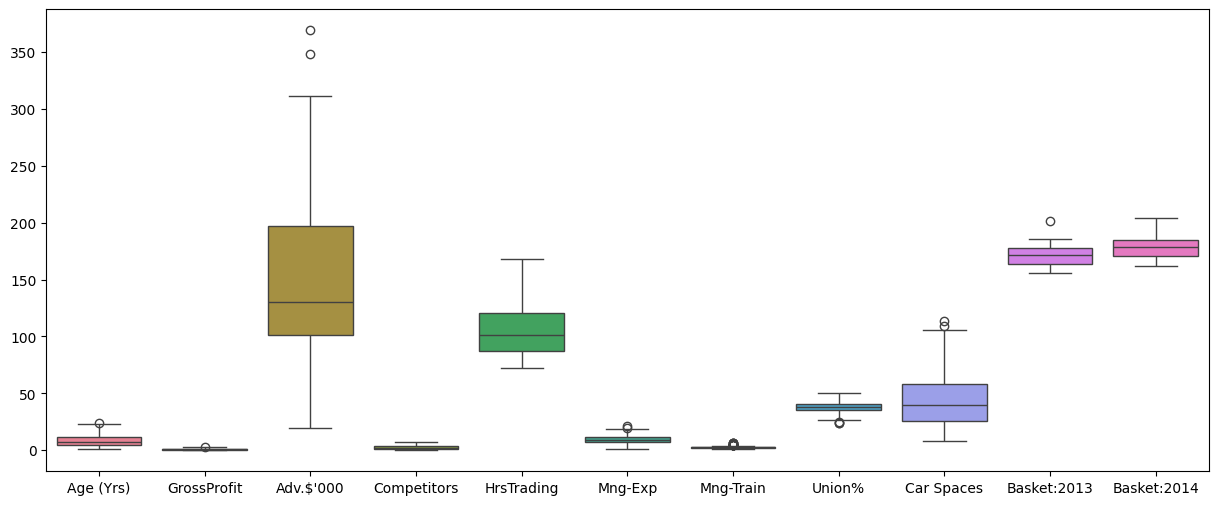

In [11]:
plt.figure(figsize=(15,6))
sns.boxplot(data=df_filtered[numerical_columns])
plt.show()

Fromn the `describe()` function and the boxplots, we notice that some of the non-categorical columns/features appear to have outliers, so we attempt to remove them.


In [12]:
for col in numerical_columns:
    Q1 = df_filtered[col].quantile(0.25)
    Q3 = df_filtered[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_filtered = df_filtered[(df_filtered[col] >= lower_bound) & (df_filtered[col] <= upper_bound)]

Before moving on, we'll keep a copy of the preprocessed dataset as a backup and because we'll be using it later.


In [13]:
df_copy = df_filtered.copy()
df_copy.head()

,Loc'n (Num),State (Num),Age (Yrs),GrossProfit,Adv.$'000,Competitors,HrsTrading,Sundays (Num),Mng-Sex (Num),Mng-Exp,Mng-Train,Union%,Car Spaces,HomeDel (Num),Basket:2013,Basket:2014
Store No.,,,,,,,,,,,,,,,,
1,2,1,10,0.712,171,3,110,0,0,12,2,38,46,0,171,178
2,2,2,8,0.091,213,5,134,0,0,16,1,38,73,0,168,178
3,3,2,7,1.075,255,2,98,1,0,9,2,39,64,0,180,188
4,2,3,7,1.372,287,1,85,1,0,9,2,38,66,1,173,180
5,1,3,15,2.148,112,0,72,1,0,4,3,40,29,0,166,171


### Normalization/Scaling


From the `describe()` method, we also saw that the non-categorical columns/features seems to have **various ranges of values**, so we'll apply the **_standard scaler_** on them.


In [14]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_filtered[numerical_columns])

df_scaled = df_filtered.copy()
df_scaled[numerical_columns] = scaled_data

---

## Data Mining Techniques


### Technique 1: K-Means


Before applying the K-Means technique on the dataset, we need to know the appropriate value for parameter k, hence we use the Elbow Method to choose the most appropriate value. (graph)


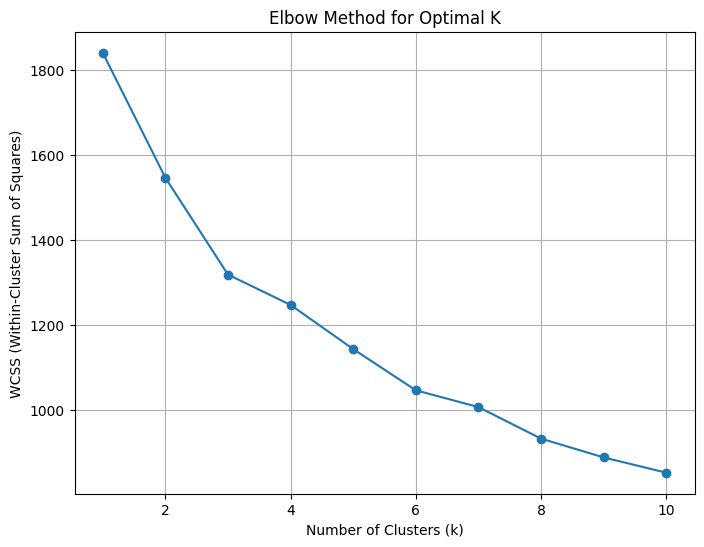

In [15]:
wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=43)
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Method graph
plt.figure(figsize=(8, 6))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.grid(True)
plt.show()

In [16]:
k = 3
kmeans = KMeans(n_clusters=k, random_state=43)
kmeans_labels = kmeans.fit_predict(df_scaled)
kmeans_labels

array([0, 1, 0, 0, 2, 0, 0, 0, 2, 0, 2, 0, 0, 2, 0, 0, 0, 1, 0, 1, 0, 0,
       2, 1, 0, 2, 0, 0, 2, 1, 1, 2, 2, 1, 2, 0, 0, 2, 2, 0, 0, 2, 2, 2,
       0, 2, 0, 1, 2, 0, 1, 2, 0, 0, 0, 0, 0, 2, 0, 0, 1, 0, 2, 2, 2, 2,
       2, 0, 0, 2, 1, 2, 1, 0, 0, 2, 0, 1, 1, 2, 0, 0, 0, 1, 2, 2, 0, 1,
       0, 0, 1, 0, 1, 1, 2, 0, 1, 0, 0, 2, 1, 2, 0, 2, 2, 2, 0, 0, 2, 0,
       0, 2, 2, 1, 0, 0, 0, 2, 1, 2, 2, 1, 1], dtype=int32)

Let's see what the summary of each cluster looks like with each feature. Here we use the `groupby()` function to help us visualize it.


In [17]:
df_filtered['kmeans_labels'] = kmeans_labels
cluster_summary = df_filtered.groupby("kmeans_labels").mean()
cluster_summary

,Loc'n (Num),State (Num),Age (Yrs),GrossProfit,Adv.$'000,Competitors,HrsTrading,Sundays (Num),Mng-Sex (Num),Mng-Exp,Mng-Train,Union%,Car Spaces,HomeDel (Num),Basket:2013,Basket:2014
kmeans_labels,,,,,,,,,,,,,,,,
0,2.392857,2.071429,7.053571,1.315732,138.303571,1.500000,93.071429,0.589286,0.089286,9.607143,2.196429,36.678571,46.285714,0.428571,176.767857,184.321429
1,1.960000,4.960000,6.080000,0.570920,153.680000,4.080000,126.440000,0.600000,0.360000,11.640000,2.640000,35.400000,42.040000,0.240000,172.120000,179.320000
2,1.333333,2.261905,13.500000,0.935286,135.928571,2.738095,109.476190,0.619048,0.190476,7.857143,2.857143,41.238095,38.333333,0.166667,165.476190,171.904762


Little information can be extracted from here, so in the Visualization section, we'll use Pair Plots to properly gather information of each cluster.

We will also evaluate the K-Means in the Silhoutte Score section.


### Technique 2: Heirarchical


For the Hierarchical Method, we used the Complete Linkage Method to cluster our data.


In [18]:
z1 = linkage(df_scaled, method='complete', metric='euclidean')

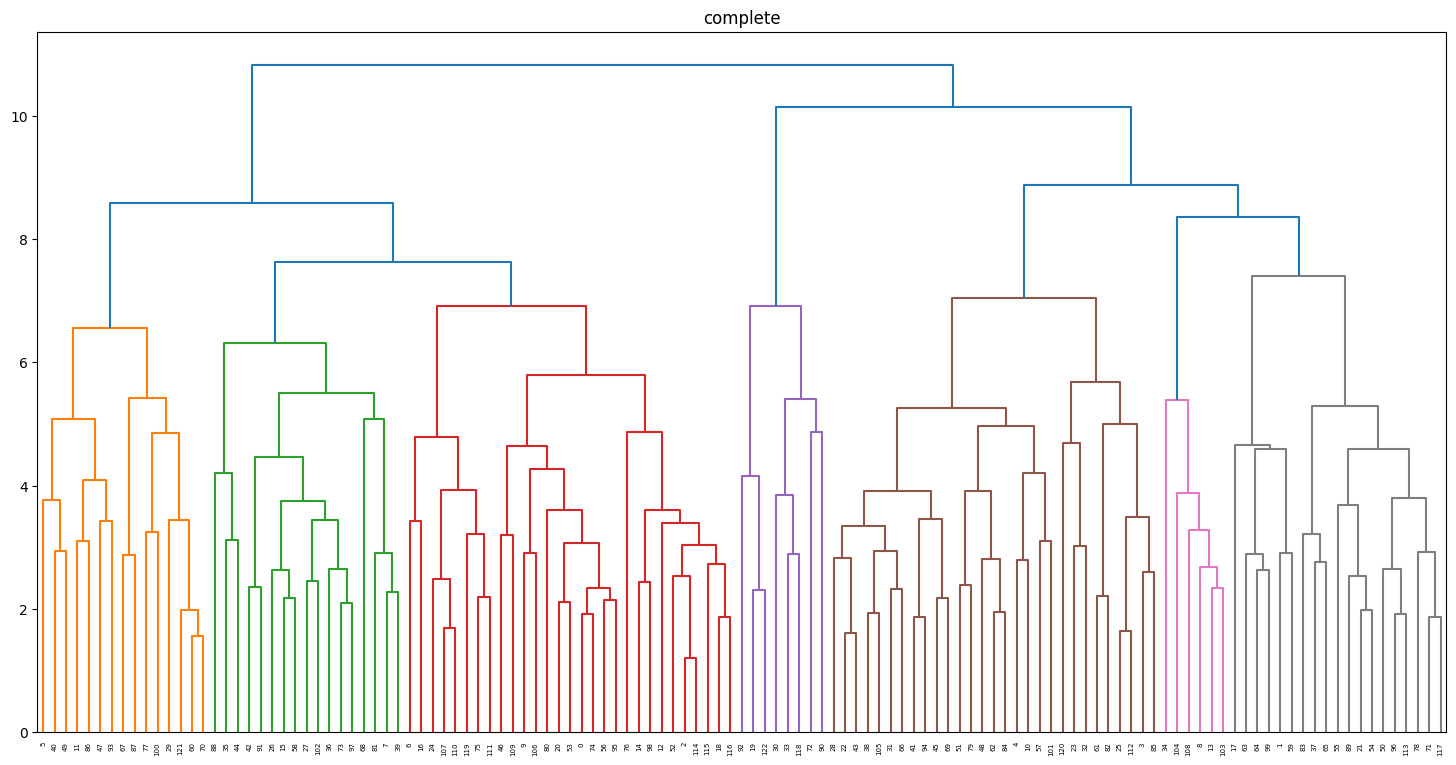

In [19]:
plt.figure(figsize=(40,20))
plt.subplot(2,2,1) , dendrogram(z1) , plt.title('complete')
plt.show()

From the Dendrogram, it's obvious to us that it would be best if we cut it at **height 9-10**, where it would produce **3 clusters**, just like the K-Means method did.


In [20]:
hierarchical_labels = fcluster(z1,3,criterion="maxclust") - 1
hierarchical_labels

array([0, 2, 0, 2, 2, 0, 0, 0, 2, 0, 2, 0, 0, 2, 0, 0, 0, 2, 0, 1, 0, 2,
       2, 2, 0, 2, 0, 0, 2, 0, 1, 2, 2, 1, 2, 0, 0, 2, 2, 0, 0, 2, 0, 2,
       0, 2, 0, 0, 2, 0, 2, 2, 0, 0, 2, 2, 0, 2, 0, 2, 0, 2, 2, 2, 2, 2,
       2, 0, 0, 2, 0, 2, 1, 0, 0, 0, 0, 0, 2, 2, 0, 0, 2, 2, 2, 2, 0, 0,
       0, 2, 1, 0, 1, 0, 2, 0, 2, 0, 0, 2, 0, 2, 0, 2, 2, 2, 0, 0, 2, 0,
       0, 0, 2, 2, 0, 0, 0, 2, 1, 0, 2, 0, 1], dtype=int32)

## Unsuccessful Techniques


Here we categorized these techniques as unsuccessful because, as we will see later in the Silhoutte Score and Visualization sections, they **performed poorly**, in comparison to the Hierarchical and K-Means techniques.


### Technique 3: K-Medoids


In [21]:
k = 3
km = KMedoids(n_clusters =  k, metric= "manhattan", init= "heuristic")
kmedoids_labels = km.fit_predict(df_scaled)
kmedoids_labels

array([2, 2, 0, 0, 0, 0, 2, 2, 1, 0, 0, 0, 2, 2, 2, 1, 0, 2, 2, 1, 2, 2,
       0, 1, 2, 0, 0, 1, 1, 1, 2, 1, 0, 2, 2, 0, 0, 1, 0, 0, 0, 1, 1, 1,
       0, 1, 1, 0, 0, 0, 1, 0, 0, 2, 2, 0, 2, 0, 0, 2, 1, 0, 1, 2, 2, 2,
       0, 0, 0, 1, 1, 0, 2, 0, 2, 2, 2, 2, 1, 0, 2, 2, 0, 1, 1, 0, 0, 0,
       0, 2, 1, 0, 2, 0, 1, 2, 1, 0, 2, 2, 0, 0, 1, 1, 2, 0, 2, 1, 0, 0,
       2, 0, 0, 1, 0, 0, 2, 1, 2, 2, 0, 1, 1])

### Technique 4: DBSCAN


In [22]:
dbscan = DBSCAN(eps=2.9, min_samples=5)
dbscan_labels = dbscan.fit_predict(df_scaled)
dbscan_labels

array([ 0,  0,  0,  0,  0, -1,  0,  0,  0,  0,  0, -1,  0,  0,  0,  0,  0,
       -1,  0, -1,  0,  0,  0, -1,  0,  0,  0,  0,  0, -1, -1,  0,  0, -1,
       -1, -1,  0, -1,  0,  0, -1,  0,  0,  0, -1,  0, -1, -1,  0,  0,  1,
        0,  0,  0,  0, -1,  0,  0,  0, -1, -1, -1,  0,  0,  0,  0,  0, -1,
       -1,  0,  0,  1, -1,  0,  0,  0, -1, -1,  0,  0,  0,  0, -1, -1,  0,
        0, -1, -1, -1,  0, -1,  0, -1, -1,  0,  0,  1,  0,  0,  0, -1,  0,
        0,  0, -1,  0, -1,  0,  0, -1,  0,  0,  0,  1,  0,  0,  0,  1, -1,
        0, -1, -1, -1])

### Technique 5: HDBSCAN


In [23]:
clusterer = hdbscan.HDBSCAN(min_cluster_size=2)
hdbscan_labels = clusterer.fit_predict(df_scaled)
hdbscan_labels

array([ 1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,
       -1,  1, -1,  1,  1,  1, -1,  1, -1,  1,  1,  1, -1, -1,  1, -1,  0,
       -1, -1,  1,  1,  1,  1, -1,  1,  1,  1, -1,  1, -1, -1,  1,  1,  1,
        1,  1,  1,  1, -1,  1,  1,  1, -1,  1, -1,  1,  1,  1,  1,  1, -1,
       -1,  1,  1,  1, -1,  1,  1,  1, -1, -1,  1,  1,  1,  1, -1, -1,  1,
        1,  1, -1, -1,  1, -1,  1, -1, -1,  1,  1,  1,  1,  1,  1, -1,  1,
        1,  1, -1,  1, -1,  1, -1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  0,
       -1, -1,  1, -1])

---

## Silhouette Score


In [24]:
# For KMeans
score_kmeans = silhouette_score(df_scaled, kmeans.labels_)
print(f"KMeans Silhouette Score: {score_kmeans:.2f}")

# For Hierarchical
score_hier = silhouette_score(df_scaled, hierarchical_labels)
print(f"Hierarchical Silhouette Score: {score_hier:.2f}")\

# For KMedoids
score_kmedoids = silhouette_score(df_scaled, km.labels_)
print(f"KMedoids Silhouette Score: {score_kmedoids:.2f}")

# For DBSCAN
score_hier = silhouette_score(df_scaled, dbscan_labels)
print(f"DBSCAN Silhouette Score: {score_hier:.2f}")

# For HDBSCAN
score_hier = silhouette_score(df_scaled, hdbscan_labels)
print(f"HDBSCAN Silhouette Score: {score_hier:.2f}")

KMeans Silhouette Score: 0.16
Hierarchical Silhouette Score: 0.12
KMedoids Silhouette Score: 0.05
DBSCAN Silhouette Score: 0.05
HDBSCAN Silhouette Score: 0.06


Silhouette Scores tells us the out of the **5 techniques**, only the first 2 were most reliable. This will be more clear to us in the Visualization section when we look at different graphs.


Before we move along, we'll add each technique's **labels/outputs** separately, in new columns, in the dataframe we copied a while ago.


In [25]:
df_copy['kmeans_cluster'] = kmeans_labels
df_copy['kmedoids_cluster'] = kmedoids_labels
df_copy['hierarchical_cluster'] = hierarchical_labels
df_copy['dbscan_cluster'] = dbscan_labels
df_copy['hdbscan_cluster'] = hdbscan_labels
df_copy.head()

,Loc'n (Num),State (Num),Age (Yrs),GrossProfit,Adv.$'000,Competitors,HrsTrading,Sundays (Num),Mng-Sex (Num),Mng-Exp,...,Union%,Car Spaces,HomeDel (Num),Basket:2013,Basket:2014,kmeans_cluster,kmedoids_cluster,hierarchical_cluster,dbscan_cluster,hdbscan_cluster
Store No.,,,,,,,,,,,,,,,,,,,,,
1,2,1,10,0.712,171,3,110,0,0,12,...,38,46,0,171,178,0,2,0,0,1
2,2,2,8,0.091,213,5,134,0,0,16,...,38,73,0,168,178,1,2,2,0,1
3,3,2,7,1.075,255,2,98,1,0,9,...,39,64,0,180,188,0,0,0,0,1
4,2,3,7,1.372,287,1,85,1,0,9,...,38,66,1,173,180,0,0,2,0,1
5,1,3,15,2.148,112,0,72,1,0,4,...,40,29,0,166,171,2,0,2,0,1


---

## Visualization


Here we cover 3 types of plots/graphs to analyze and visualize our techniques.

First, we use Pair Plots to look at how our features are clustered using the K-Means technique.


### Pair Plots


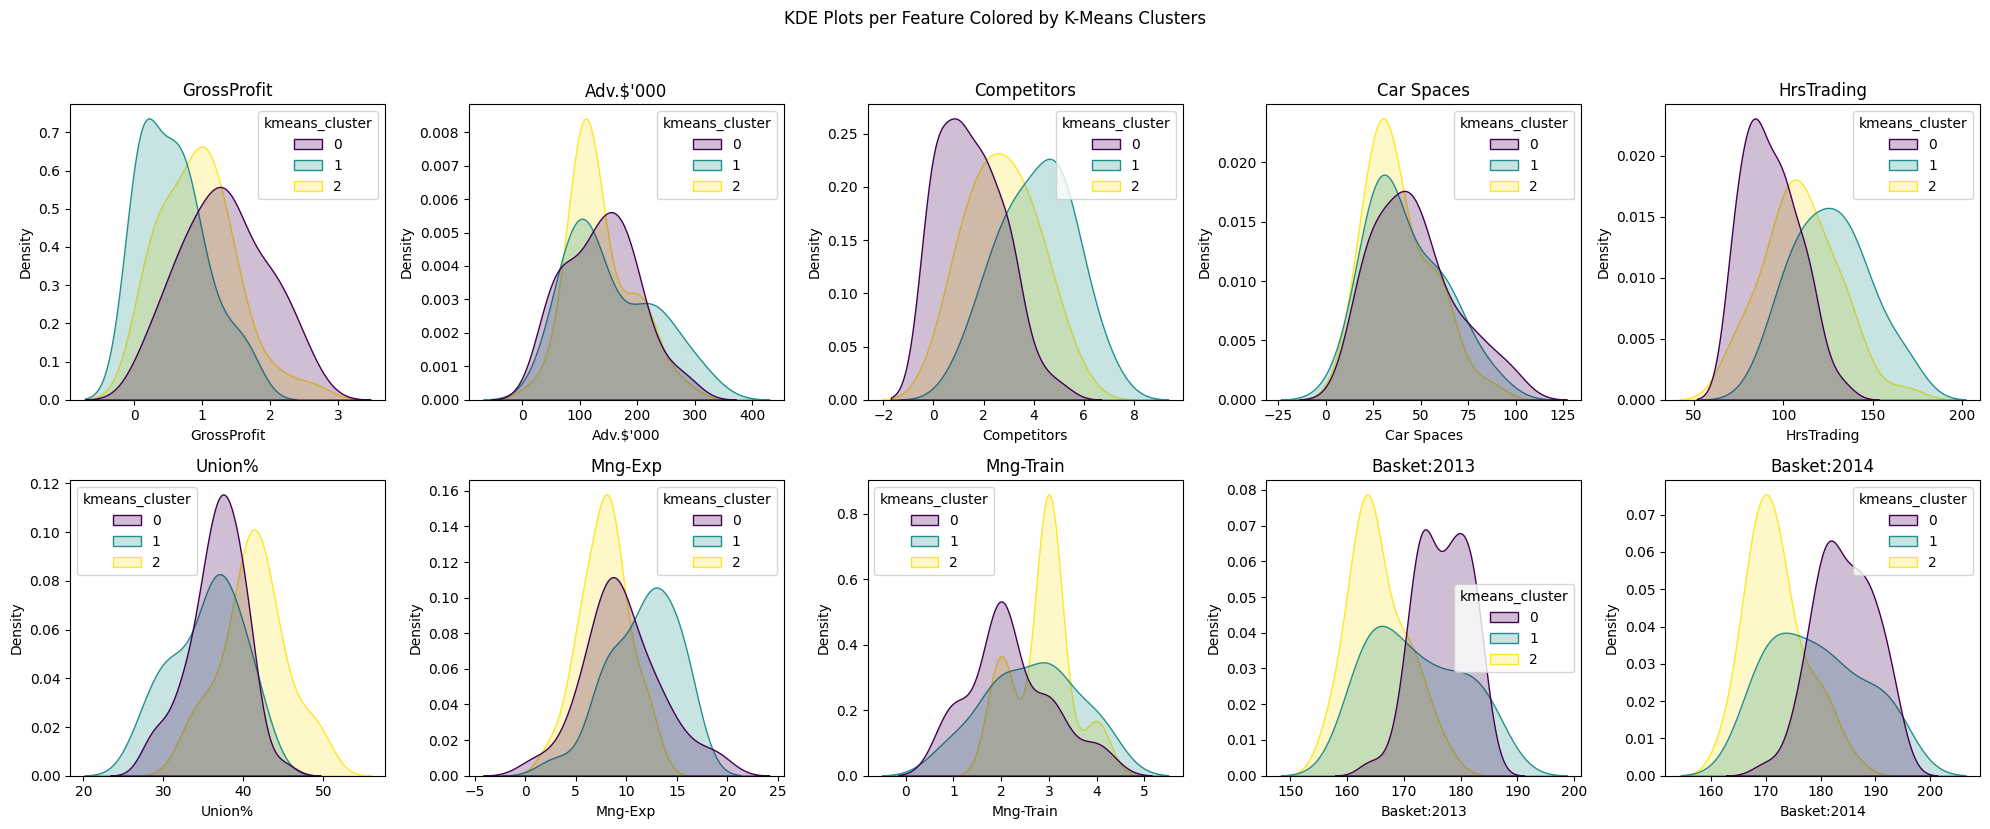

In [26]:
# Features to plot (excluding 'kmeans_cluster')
plotting_features = ['GrossProfit', 'Adv.$\'000', 'Competitors', 'Car Spaces',
                     "HrsTrading", "Union%", "Mng-Exp", "Mng-Train", 'Basket:2013', 'Basket:2014']

# Set up 2x5 subplot grid
n_rows, n_cols = 2, 5
fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(20, 8))

for i, feature in enumerate(plotting_features):
    row, col = divmod(i, n_cols)
    ax = axes[row, col]
    sns.kdeplot(
        data=df_copy,
        x=feature,
        hue='kmeans_cluster',
        palette='viridis',
        ax=ax,
        fill=True,
        common_norm=False
    )
    ax.set_title(feature)

plt.suptitle("KDE Plots per Feature Colored by K-Means Clusters", y=1.03)
plt.tight_layout()
plt.show()


Cluster 0:

- Gross Profit: highest
- Advertisement Spending: highest
- Competitors Count: lowest
- Car Slots: highest
- Hours Trading: lowest
- Union Percentage: moderate
- Manager Experience: moderate
- Manager Training: lowest
- Basket in 2014: highest
- Basket in 2013: highest

Cluster 1:

- Gross Profit: lowest
- Advertisement Spending: moderate
- Competitors Count: highest
- Car Slots: moderate
- Hours Trading: highest
- Union Percentage: moderate
- Manager Experience: highest
- Manager Training: moderate
- Basket in 2014: moderate
- Basket in 2013: moderate

Cluster 2:

- Gross Profit: moderate
- Advertisement Spending: moderate
- Competitors Count: moderate
- Car Slots: moderate
- Hours Trading: moderate
- Union Percentage: highest
- Manager Experience: moderate
- Manager Training: moderate
- Basket in 2014: lowest
- Basket in 2013: lowest


Conclusion:

Cluster 0 includes high-performing stores with strong profits and basket sizes, driven by low competition and high advertisement spenditure.

Cluster 1 include less performing stores, with experienced managers and long hours. Struggles with profit, likely due to high competition.

Cluster 2 shows the lowest performance overall, with high union presence and modest metrics across the board.


### Scatter Plots


Now, we'll see, visually, how each technique performed with the clusters they produced. But before that, we have to apply the dimensionality reduction method "PCA" to be able to visualize them in 2D, since we're dealing with a dataset of high dimensions (features).

PCA will fit all the features into 2 dimensions and then we'll visualize each method.


In [27]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(df_scaled)

In [28]:
# Dictionaries

# Dictionary for method names(value) and their labels in the dataset(key)
cluster_dict = {
    'kmeans_cluster': 'KMeans',
    'hierarchical_cluster': 'Hierarchical',
    'kmedoids_cluster': 'KMedoids',
    'dbscan_cluster': 'DBSCAN',
    'hdbscan_cluster': 'HDBSCAN'
}

# Dictionary for legend
legend_labels = {
    -1: "Outlier",
     0: "Cluster 0",
     1: "Cluster 1",
     2: "Cluster 2"
}

# Dictionary for fixing the color of legends
fixed_palette = {
    "Cluster 0": "orange",
    "Cluster 1": "lightblue",
    "Cluster 2": "pink",
    "Outlier": "red"
}


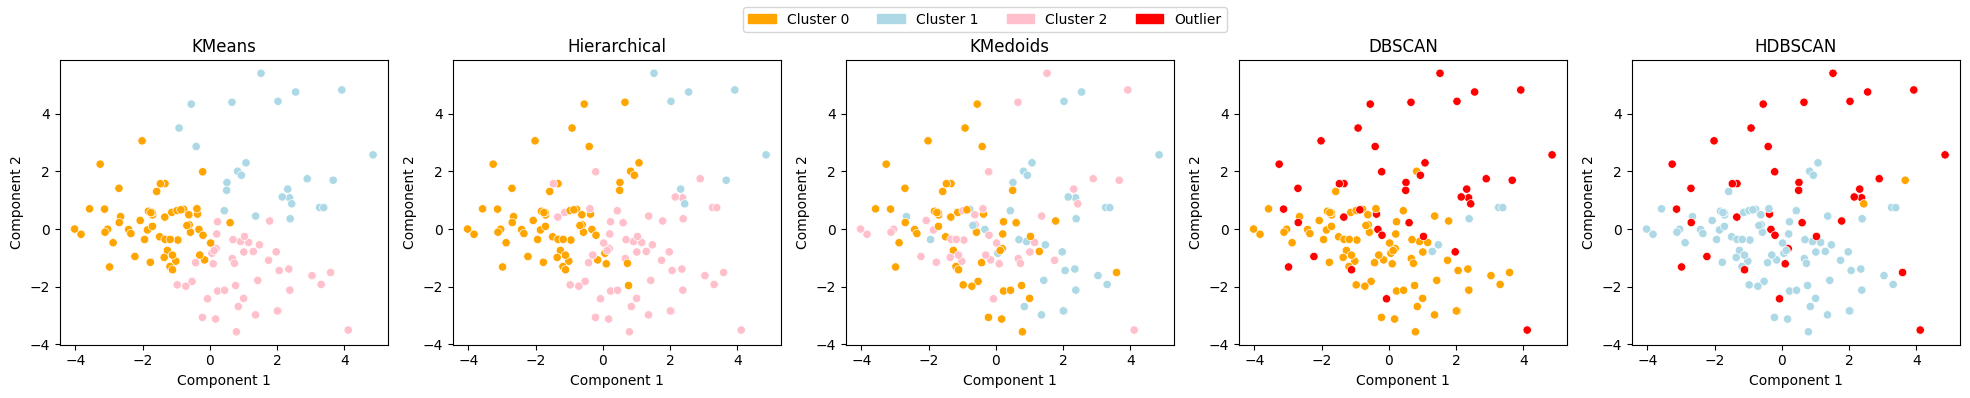

In [29]:
# Create 1x5 subplots
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
axes = axes.flatten()

# Plot each clustering labels results with the original data
for i, (col_name, method_name) in enumerate(cluster_dict.items()):
    sns.scatterplot(
        x=X_pca[:, 0],
        y=X_pca[:, 1],
        hue=df_copy[col_name].map(legend_labels),
        palette=fixed_palette,
        ax=axes[i],
        legend=False  # Suppress individual legends
    )
    axes[i].set_title(f"{method_name}")
    axes[i].set_xlabel("Component 1")
    axes[i].set_ylabel("Component 2")

# Create shared legend
handles = [Patch(color=fixed_palette[label], label=label) for label in fixed_palette]
fig.legend(handles=handles,  loc='upper center', ncol=len(fixed_palette))
# Adjust layout to make space for the legend
plt.tight_layout(rect=[0, 0, 0.9, 0.95])
plt.show()

Here we can see how **K-Means** is well segmented compared to the rest, with barely any overlaps. **Hierarchical** also follows the same concept but with a little bit more overlap.

**K-Medoids**, on the other hand, is seen to be overlapping, hence its low Solhouette Score.

Finally, **DBSCAN** & **HDBSCAN** both seem to produce similar clusters. They're both visibly inefficient because a lot of outliers are visible and overlapping.


### Pie Chart


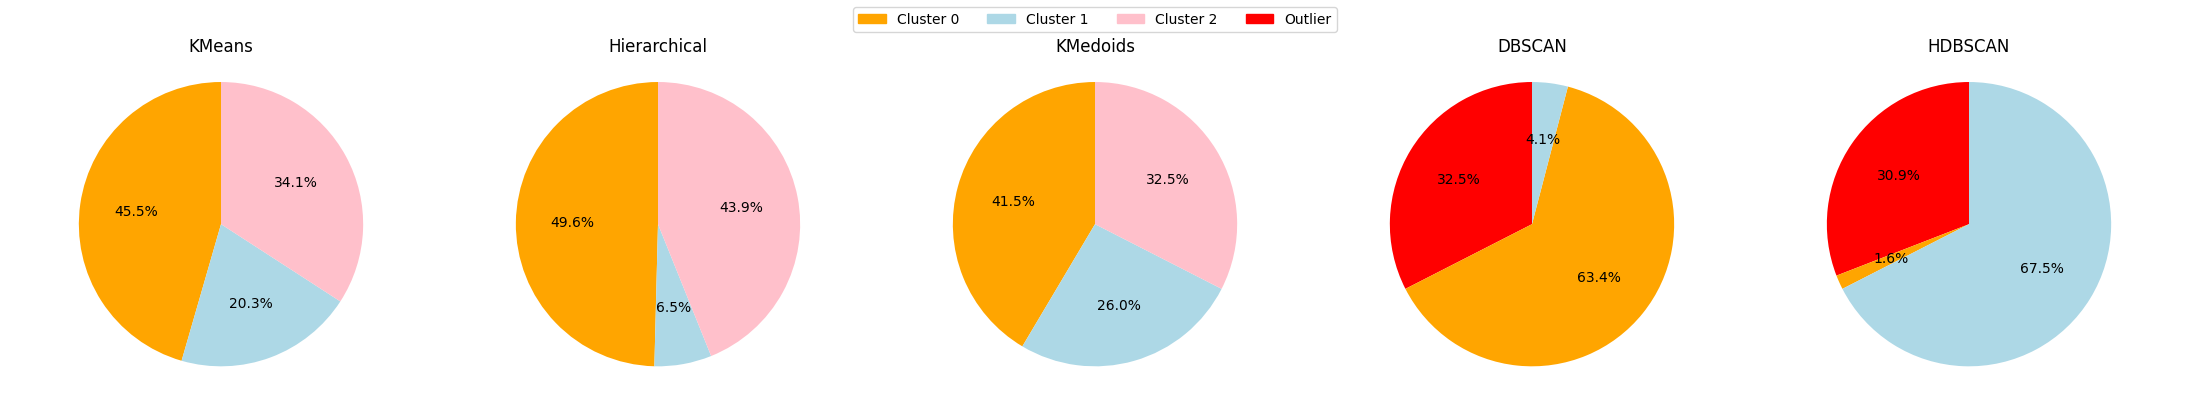

In [30]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Create legend handles from fixed_palette
legend_patches = [Patch(color=fixed_palette[label], label=label) for label in fixed_palette]

# Create 1x5 subplots for the clustering pie charts
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
axes = axes.flatten()

# Plot each clustering result as a pie chart
for i, (col_name, method_name) in enumerate(cluster_dict.items()):
    cluster_counts = df_copy[col_name].value_counts().sort_index()
    labels = cluster_counts.index.map(legend_labels)
    colors = [fixed_palette[label] for label in labels]

    axes[i].pie(
        cluster_counts,
        labels=None,
        autopct='%1.1f%%',
        startangle=90,
        colors=colors
    )
    axes[i].set_title(f"{method_name}")
    axes[i].axis('equal')

# Add a shared legend above all plots
fig.legend(handles=legend_patches, loc='upper center', ncol=len(fixed_palette))

# Adjust layout to prevent overlap
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

---

# Classification


## Data Splitting


In [31]:
df_new = df_scaled.copy()
df_new['KMeans_Cluster'] = kmeans_labels
df_new.head()

,Loc'n (Num),State (Num),Age (Yrs),GrossProfit,Adv.$'000,Competitors,HrsTrading,Sundays (Num),Mng-Sex (Num),Mng-Exp,Mng-Train,Union%,Car Spaces,HomeDel (Num),Basket:2013,Basket:2014,KMeans_Cluster
Store No.,,,,,,,,,,,,,,,,,
1,2,1,0.175581,-0.500455,0.483626,0.328483,0.201929,0,0,0.722285,-0.603043,0.005377,0.163900,0,-0.129437,-0.130064,0
2,2,2,-0.196771,-1.464304,1.152186,1.516820,1.268290,0,0,1.843308,-1.780414,0.005377,1.507884,0,-0.530799,-0.130064,1
3,3,2,-0.382948,0.062954,1.820747,-0.265685,-0.331251,1,0,-0.118482,-0.603043,0.225828,1.059890,0,1.074650,1.091150,0
4,2,3,-0.382948,0.523926,2.330126,-0.859853,-0.908863,1,0,-0.118482,-0.603043,0.005377,1.159444,1,0.138138,0.114179,0
5,1,3,1.106461,1.728349,-0.455543,-1.454021,-1.486475,1,0,-1.519760,0.574327,0.446280,-0.682312,0,-0.798373,-0.984914,2


In [32]:
X = df_new.drop(columns=['KMeans_Cluster'])
y = df_new['KMeans_Cluster']

In [33]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

## Random Forest Classifier


In [34]:
model = RandomForestClassifier()
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

## Evaluation Metrics


In [35]:
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      0.89      0.84         9
           1       0.83      1.00      0.91         5
           2       1.00      0.82      0.90        11

    accuracy                           0.88        25
   macro avg       0.88      0.90      0.88        25
weighted avg       0.89      0.88      0.88        25

[[8 1 0]
 [0 5 0]
 [2 0 9]]
